In [351]:
import torch 
import pandas as pd 
import numpy as np
import os
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader 

from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from lincs_gsnn.models.ODEFunc import ODEFunc
from lincs_gsnn.data.TrajDataset import TrajDataset
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torchdiffeq import odeint 

from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.IGExplainer import IGExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
from gsnn.interpret.NoiseTunnel import NoiseTunnel
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.OcclusionExplainer import OcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance, plot_node_importance
from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer
from gsnn.interpret.ContrastiveGSNNExplainer import ContrastiveGSNNExplainer

from gsnn.interpret.utils import plot_edge_importance, plot_node_importance

import networkx as nx

import seaborn as sbn
import gseapy as gp

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



Lapatinib (EGFR/HER2 inhibitor) – HER2-amplified vs HER2-normal cells: If lapatinib strongly suppresses HER2-driven signaling in HER2-amplified breast cells (e.g. SKBR3 or BT-474, leading to lowered CCND1 (Cyclin D1) and increased CDKN1B (p27) expression) but has minimal effect in HER2-nonamplified cells (e.g. T47D or MCF7, which show little transcriptional response to lapatinib), due to the lack of HER2-driven pathway activity in the latter, then MyModel should predict pronounced downregulation of CCND1 (and upregulation of cell-cycle inhibitors) in SKBR3/BT-474 but not in T47D/MCF7. The model’s explanations should point to the HER2/EGFR signaling network as the mediator of this difference – for example, highlighting that HER2–ERK/PI3K pathway inhibition drives the gene expression changes in HER2-dependent cells, whereas in HER2-normal cells that pathway was not active


Early time points (≤12 hours):
Gene expression studies in HER2-amplified lines (e.g., BT-474, SKBR3) observed significant downregulation of CCND1 as early as ~12 hours after lapatinib treatment, making it one of the early transcriptional responses. This effect was proportional to lapatinib sensitivity. 
SpringerLink
+1

In [833]:
root_gsnn = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_included'
root_traj = '/home/teddy/local/workflow_outputs/lincs-traj/default_v03_from_arc'

sample_id = 'sample_13'

dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')


In [834]:
data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)
model = torch.load(os.path.join(root_gsnn, f'pretrain/pretrained_model_{sample_id}.pt'), weights_only=False)
dxdt_scale = torch.load(os.path.join(root_gsnn, f'pretrain/dxdt_scale_{sample_id}.pt'), weights_only=False).item()
x_names = pd.read_csv(os.path.join(root_traj, 'predict_grid/gene_names.csv'))['gene_names'].values.astype(str).tolist()
dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))

In [835]:
dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))
dxdt_meta.head()

,pert_id,cell_iname,dose,time,file_name
0,BRD-K49328571,HME1,0.0,0.000000,dxdt__BRD-K49328571_HME1_0.0_0.pt
1,BRD-K49328571,HME1,0.0,1.469388,dxdt__BRD-K49328571_HME1_0.0_1.pt
2,BRD-K49328571,HME1,0.0,2.938776,dxdt__BRD-K49328571_HME1_0.0_2.pt
3,BRD-K49328571,HME1,0.0,4.408163,dxdt__BRD-K49328571_HME1_0.0_3.pt
4,BRD-K49328571,HME1,0.0,5.877551,dxdt__BRD-K49328571_HME1_0.0_4.pt


In [836]:
# freeze the model 
for param in model.parameters():
    param.requires_grad = False
model = model.eval() 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [837]:
dxdt_meta.cell_iname.unique()

array(['HME1', 'BT20', 'BT474', 'HS578T', 'MCF10A', 'MCF7', 'MDAMB231',
       'MDAMB468', 'SKBR3', 'T47D', 'ZR751'], dtype=object)

In [838]:
dxdt_meta.pert_id.unique()

array(['BRD-K49328571', 'BRD-K51544265', 'BRD-K92723993', 'BRD-K81528515',
       'BRD-K99964838', 'BRD-K44227013', 'BRD-K33379087', 'BRD-K42828737',
       'BRD-K54997624', 'BRD-K12343256', 'BRD-K19687926', 'BRD-M07438658',
       'BRD-K51313569'], dtype=object)

In [839]:
class ODEWrapper(torch.nn.Module): 

    def __init__(self, model, data, dxdt_scale, method='dopri5', 
                    tol=1e-4, t=torch.linspace(0, 72, 50)):
        
        super().__init__()

        self.model_ = model
        self.ode_func = ODEFunc(model, data.node_names_dict['input'], scale=dxdt_scale)
        self.data_ = data
        self.dxdt_scale_ = dxdt_scale
        self.method_ = method
        self.tol_ = tol
        self.t_ = t
        self.edge_index = model.edge_index
        self.homo_names = model.homo_names
        self.num_nodes = model.num_nodes

    
    def forward(self, x0, edge_mask=None, node_mask=None):

        B, N = x0.shape

        if B > 1: 
            raise ValueError('Batch size must be 1')

        xt = self.ode_func.integrate(x = x0, 
                                     time = self.t_,
                                     node_mask=node_mask, 
                                     edge_mask=edge_mask, 
                                     method=self.method_, 
                                     tol=self.tol_)

        return xt.squeeze(1)       # (T, N)
    

In [840]:
# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?


# https://www.nature.com/articles/cddis2017294 
drug = 'BRD-M07438658' #'BRD-K19687926'  # lapatinib (EGFR) # 'BRD-M07438658',  # lapatinib (EGFR) 
dose = 10.0

cell1 = 'BT474' # 'SKBR3' # or BT-474 # HER2 Amplified 
cell2 = 'MCF7' #'T47D' #or MCF7 # HER2 non-amplified


target_gene = 'GENE__CDKN1B' #'GENE__CCND1' # CCND1 (Cyclin D1) and increased CDKN1B (p27) expression)
target_ix = data.node_names_dict['output'].index(target_gene)        

In [841]:
np.sort([x.split('__')[1] for x in data.node_names_dict['output'] if x.split('__')[1][0:3] == 'CDK'])

array(['CDK1', 'CDK19', 'CDK2', 'CDK4', 'CDK5R1', 'CDK6', 'CDK7',
       'CDKN1A', 'CDKN1B', 'CDKN2A'], dtype='<U6')

In [842]:
cond1 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                    & (dxdt_meta['cell_iname'] == cell1) 
                    & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

cond2 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                    & (dxdt_meta['cell_iname'] == cell2) 
                    & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

print(cond1.shape)
print(cond2.shape)

(50, 5)
(50, 5)


In [843]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [844]:
dataset1 = DXDTDataset(meta=cond1, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

dataloader1 = DataLoader(dataset1, batch_size=8, shuffle=False)

In [845]:
dataset2 = DXDTDataset(meta=cond2, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

dataloader2 = DataLoader(dataset2, batch_size=8, shuffle=False)

In [846]:
def retrieve_data(dataloader):

    xs = []; ys = [] 
    for i, (x, y) in enumerate(dataloader):
        xs.append(x)
        ys.append(y)
    xs = torch.cat(xs, dim=0)
    ys = torch.cat(ys, dim=0)

    return xs, ys 

x1, y1 = retrieve_data(dataloader1)
x2, y2 = retrieve_data(dataloader2)

x0_1 = x1[[0]] # MDAMB231
x0_2 = x2[[0]] # MCF7

In [847]:
t = torch.linspace(0, 72, x1.shape[0], device=device)

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      t=t, 
                      method= 'euler', 
                      tol=None)

x1_t_hat = ode_gsnn(x0_1.to(device))
x2_t_hat = ode_gsnn(x0_2.to(device))

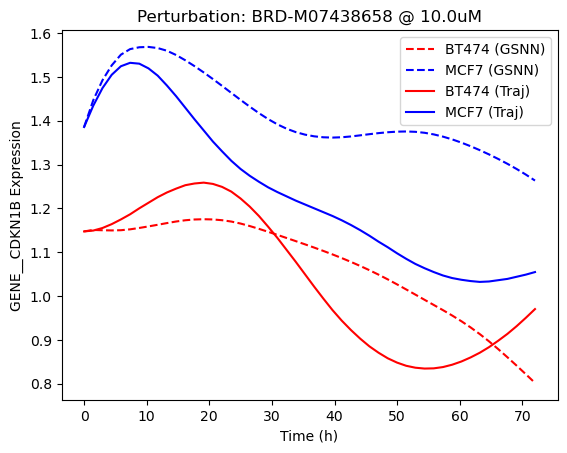

In [848]:
plt.figure()
plt.plot(t.detach().cpu().numpy(), x1_t_hat[:, target_ix].detach().cpu().numpy(), 'r--', label=f'{cell1} (GSNN)')
plt.plot(t.detach().cpu().numpy(), x2_t_hat[:, target_ix].detach().cpu().numpy(), 'b--', label=f'{cell2} (GSNN)')
plt.plot(t.detach().cpu().numpy(), x1[:, target_ix].detach().cpu().numpy(), 'r-', label=f'{cell1} (Traj)')
plt.plot(t.detach().cpu().numpy(), x2[:, target_ix].detach().cpu().numpy(), 'b-', label=f'{cell2} (Traj)')
plt.title(f'Perturbation: {drug} @ {dose}uM')
plt.xlabel('Time (h)')
plt.ylabel(f'{target_gene} Expression')
plt.legend()
plt.show()

In [624]:
t = torch.linspace(0, 30, 20, device=device)

In [369]:
ode_params = {'t': t, 
              'method': 'euler', 
              'tol': None} 


gsnn_explainer_params = {'hard': False, 
                         'beta': 5e-4, 
                         'lr': 5e-2, 
                         'prior': 5, 
                         'iters': 250, 
                         'entropy': 1., 
                         'grad_norm_clip': 1.0, 
                         'free_edges': 100} 


# CELL1 explanation

In [370]:

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)

explainer = GSNNExplainer(ode_gsnn, 
                          data, 
                          **gsnn_explainer_params)

gsnn_res1 = explainer.explain(x0_1.to(device), target_idx=[target_ix], target='edge')

iter: 249 | loss: 0.7357 | mse: 0.0027 | r2: 0.669 | active edges: 1293 / 43637 | entropy: 0.128871
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 30 / 43637 (0.1%)
MSE (subset): 0.002656
R² (subset): 0.6742
Variance explained: 0.8736
Correlation: 0.9347


In [371]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res1 = explainer.explain(x1.to(device), 
                                   target_idx=target_ix, 
                                   target='edge', 
                                   element_mask=gsnn_res1.score.values > 0.5) 


In [372]:
#explainer = NoiseTunnel(IGExplainer(model.to(device), data), n_samples=10, noise_std=0.1) 
explainer = IGExplainer(model.to(device), data)
ig_res1 = explainer.explain(x1.to(device), 
                            target_idx=target_ix, 
                            target='edge', 
                            reduction='sum',
                            element_mask=gsnn_res1.score.values > 0.5)

In [373]:

res1 = gsnn_res1.merge(ig_res1, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res1 = res1.merge(occlusion_res1, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res1 = res1.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
res1 = res1[lambda x: x.gsnn_score > 0.5]
#res1 = res1[lambda x: x.occlusion_score.abs() > 0.05]
print(res1.shape)
res1.head(25)

(30, 7)


,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
575,RNA__hsa-miR-15b-3p,RNA__CCND1,0.996665,-0.494249,-0.008114,0.494249,0.008114
2749,RNA__hsa-miR-19a,RNA__CCND1,0.721067,-0.346414,-0.009274,0.346414,0.009274
3649,PROTEIN__STAT3,RNA__CCND1,0.985266,0.398421,0.023559,0.398421,0.023559
3985,PROTEIN__ERBB4,PROTEIN__STAT5A,0.992669,0.040889,0.015991,0.040889,0.015991
5052,RNA__hsa-miR-1-3p,RNA__CCND1,0.867754,0.189154,-0.008873,0.189154,0.008873
5821,PROTEIN__FOXM1,RNA__CCND1,0.953509,-0.112062,-0.003571,0.112062,0.003571
8742,RNA__hsa-miR-502-5p,RNA__CCND1,0.997831,-0.180660,-0.017302,0.180660,0.017302
9424,PROTEIN__FOXO1,RNA__CCND1,0.807223,0.194187,0.032822,0.194187,0.032822
9826,PROTEIN__STAT5A,RNA__CCND1,0.986140,-0.088667,0.027872,0.088667,0.027872
9845,PROTEIN__STAT5A,RNA__hsa-miR-15b-3p,0.999325,-2.027619,-0.024817,2.027619,0.024817


In [374]:
res1[['ig_score', 'occlusion_score', 'gsnn_score', 'abs_ig_score', 'abs_oc_score']].corr(method='spearman')

,ig_score,occlusion_score,gsnn_score,abs_ig_score,abs_oc_score
ig_score,1.000000,0.648498,-0.187987,-0.448721,-0.270300
occlusion_score,0.648498,1.000000,-0.207119,-0.543493,-0.450056
gsnn_score,-0.187987,-0.207119,1.000000,0.378420,0.265406
abs_ig_score,-0.448721,-0.543493,0.378420,1.000000,0.610234
abs_oc_score,-0.270300,-0.450056,0.265406,0.610234,1.000000


In [375]:
res1.shape

(30, 7)

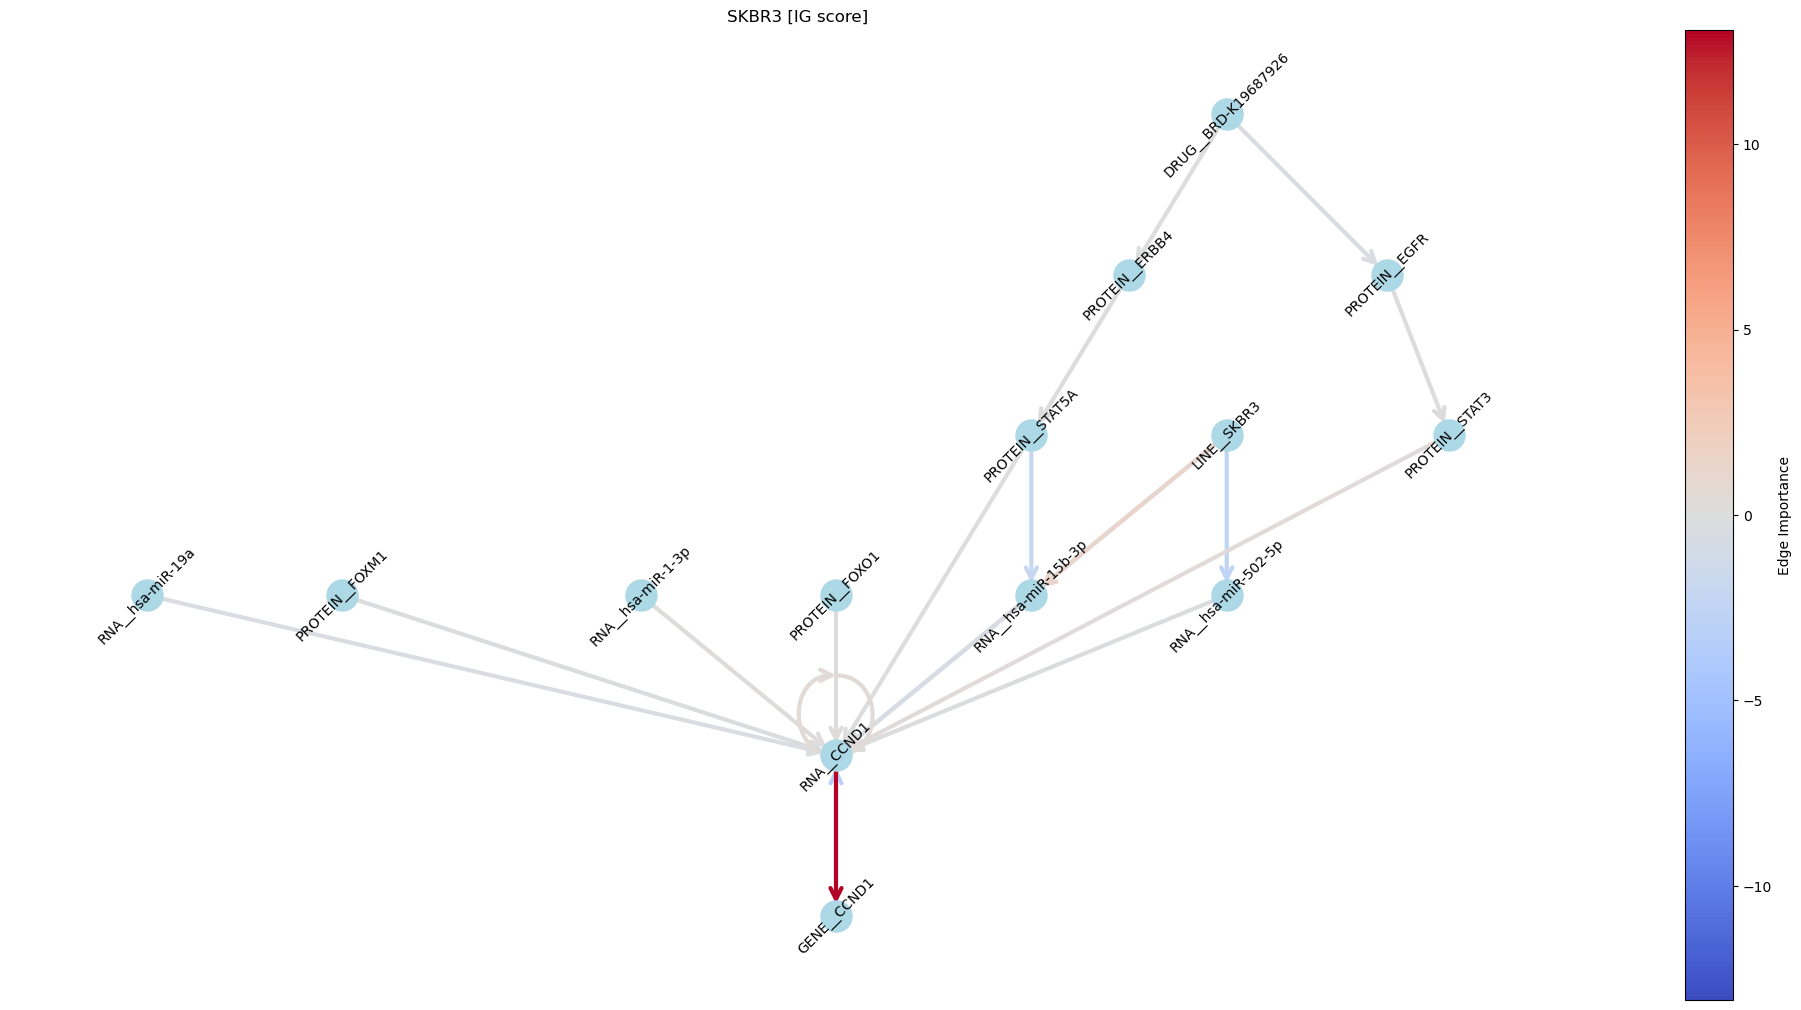

In [376]:
plot_edge_importance(res1.rename(columns={'ig_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} [IG score]')

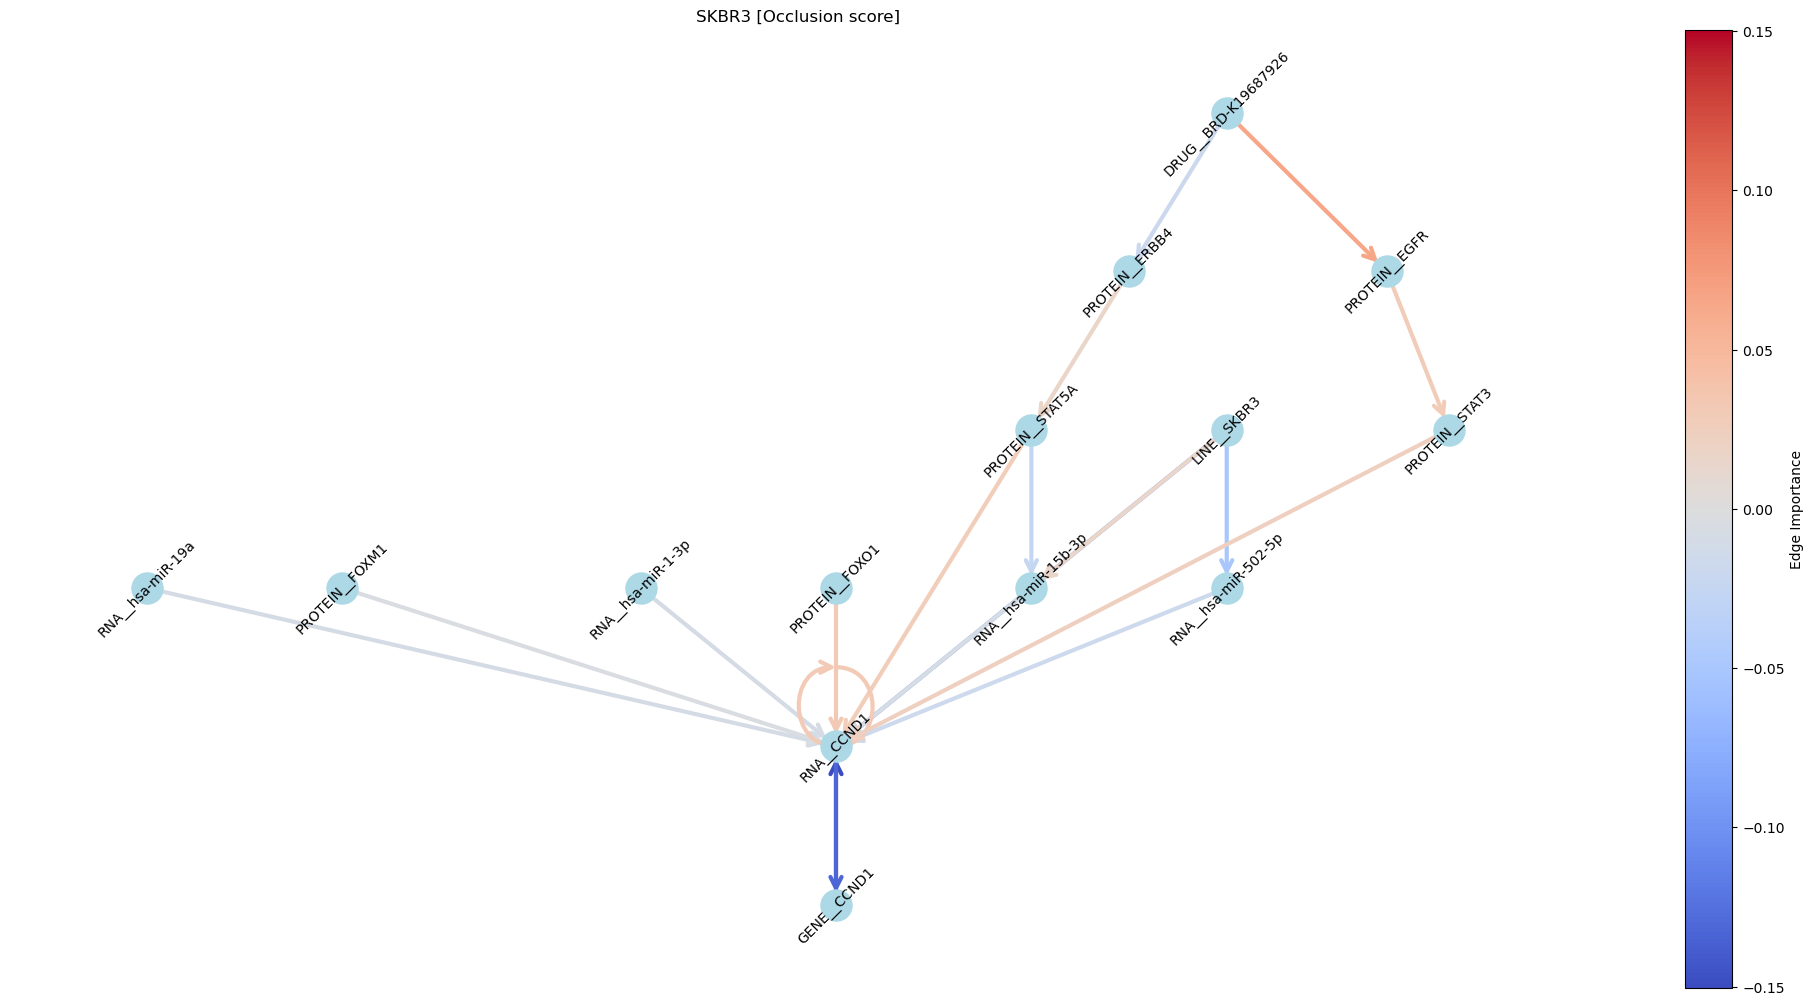

In [377]:
plot_edge_importance(res1.rename(columns={'occlusion_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} [Occlusion score]')

In [390]:
G = nx.from_pandas_edgelist(res1, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(gsnn_res1, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr1 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr1.res2d.sort_values(by='Adjusted P-value', ascending=True).head(20)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Recruitment And ATM-mediated Phosphorylation O...,0.013040
1,DNA Double Strand Break Response R-HSA-5693606,0.013040
2,Signaling By Non-Receptor Tyrosine Kinases R-H...,0.013040
3,Gastrin-CREB Signaling Pathway Via PKC And MAP...,0.013040
4,G Alpha (Q) Signaling Events R-HSA-416476,0.013040
5,Signaling By Interleukins R-HSA-449147,0.018919
9,PI3K/AKT Signaling In Cancer R-HSA-2219528,0.025526
21,Signaling By Leptin R-HSA-2586552,0.025526
10,G2/M DNA Damage Checkpoint R-HSA-69473,0.025526
6,Estrogen-dependent Nuclear Events Downstream O...,0.025526


In [391]:
# we expect MCF7 to RB1 proficent and therefore involved 
# we expect MDAMB231 to have be RB1 deficient and therefore uninvolved, what is the RB1 scores? 


res1_all = gsnn_res1.merge(ig_res1, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res1_all = res1_all.merge(occlusion_res1, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res1_all = res1_all.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs()) 

res1_all[lambda x: x.source.str.contains(f'ERBB2') | x.target.str.contains(f'ERBB4')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5]

KeyError: 'source'

In [392]:
res1_all[lambda x: x.source.str.contains(f'ERBB2') | x.target.str.contains(f'ERBB4')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].ig_score.sum()

np.float32(-0.011116769)

In [393]:
res1_all[lambda x: x.source.str.contains(f'ERBB2') | x.target.str.contains(f'ERBB4')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].occlusion_score.sum()

np.float64(-0.019307628273963928)

In [403]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res1 = explainer.explain(x0_1.to(device), 
                                   target_idx=target_ix, 
                                   target='node')

occlusion_res1.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__ERBB2') | x.node.str.contains(f'__ERBB4') | x.node.str.contains(f'__EGFR')].head()

,node,score
2285,RNA__ERBB2,5.035400e-04
3475,GENE__EGFR,-2.384186e-07
3489,GENE__ERBB2,-3.576279e-07
2474,GENE__EGFR,-3.576279e-07
2488,GENE__ERBB2,-7.152557e-07


In [404]:
explainer = IGExplainer(model.to(device), data)
ig_res1 = explainer.explain(x0_1.to(device), 
                            target_idx=target_ix, 
                            target='node', 
                            reduction='sum')

ig_res1.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__ERBB2') | x.node.str.contains(f'__ERBB4') | x.node.str.contains(f'__EGFR')].head()

,node,score
2285,RNA__ERBB2,0.000121
2488,GENE__ERBB2,0.000000
2474,GENE__EGFR,0.000000
3475,GENE__EGFR,0.000000
3489,GENE__ERBB2,0.000000


# CELL 2 Explanation 

In [384]:

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)

explainer = GSNNExplainer(ode_gsnn, 
                          data, 
                          **gsnn_explainer_params)

gsnn_res2 = explainer.explain(x0_2.to(device), target_idx=[target_ix], target='edge')

iter: 249 | loss: 0.7336 | mse: 0.0011 | r2: -1.657 | active edges: 1271 / 43637 | entropy: 0.128562
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 6 / 43637 (0.0%)
MSE (subset): 0.001062
R² (subset): -1.6572
Variance explained: 0.0000
Correlation: nan


/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [385]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res2 = explainer.explain(x0_2.to(device), 
                                   target_idx=target_ix, 
                                   target='edge', 
                                   element_mask=gsnn_res2.score.values > 0.5) 


In [386]:
explainer = IGExplainer(model.to(device), data)
ig_res2 = explainer.explain(x0_2.to(device), 
                            target_idx=target_ix, 
                            target='edge', 
                            reduction='sum',
                            element_mask=gsnn_res2.score.values > 0.5)

In [387]:
res2 = gsnn_res2.merge(ig_res2, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res2 = res2.merge(occlusion_res2, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res2 = res2.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
res2 = res2[lambda x: x.gsnn_score > 0.5]
print(res2.shape)
res2.head()

(6, 7)


,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
16443,GENE__CCND1,RNA__CCND1,0.563225,0.682077,0.675333,0.682077,0.675333
16497,GENE__CEBPA,RNA__CEBPA,0.863821,-0.121964,-0.099366,0.121964,0.099366
17098,GENE__AKT1,RNA__AKT1,0.536672,-0.174595,-0.153472,0.174595,0.153472
17341,DRUG__BRD-K19687926,PROTEIN__EGFR,0.853230,0.172910,0.257747,0.172910,0.257747
29034,LINE__MCF7,RNA__CASP3,0.749515,0.047905,0.048667,0.047905,0.048667


In [388]:
res2[['ig_score', 'occlusion_score', 'gsnn_score', 'abs_ig_score', 'abs_oc_score']].corr(method='spearman')

,ig_score,occlusion_score,gsnn_score,abs_ig_score,abs_oc_score
ig_score,1.000000,1.000000,-0.371429,0.028571,0.200000
occlusion_score,1.000000,1.000000,-0.371429,0.028571,0.200000
gsnn_score,-0.371429,-0.371429,1.000000,-0.142857,0.028571
abs_ig_score,0.028571,0.028571,-0.142857,1.000000,0.942857
abs_oc_score,0.200000,0.200000,0.028571,0.942857,1.000000


In [389]:
plot_edge_importance(res2.rename(columns={'ig_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [IG score]')

ValueError: min() iterable argument is empty

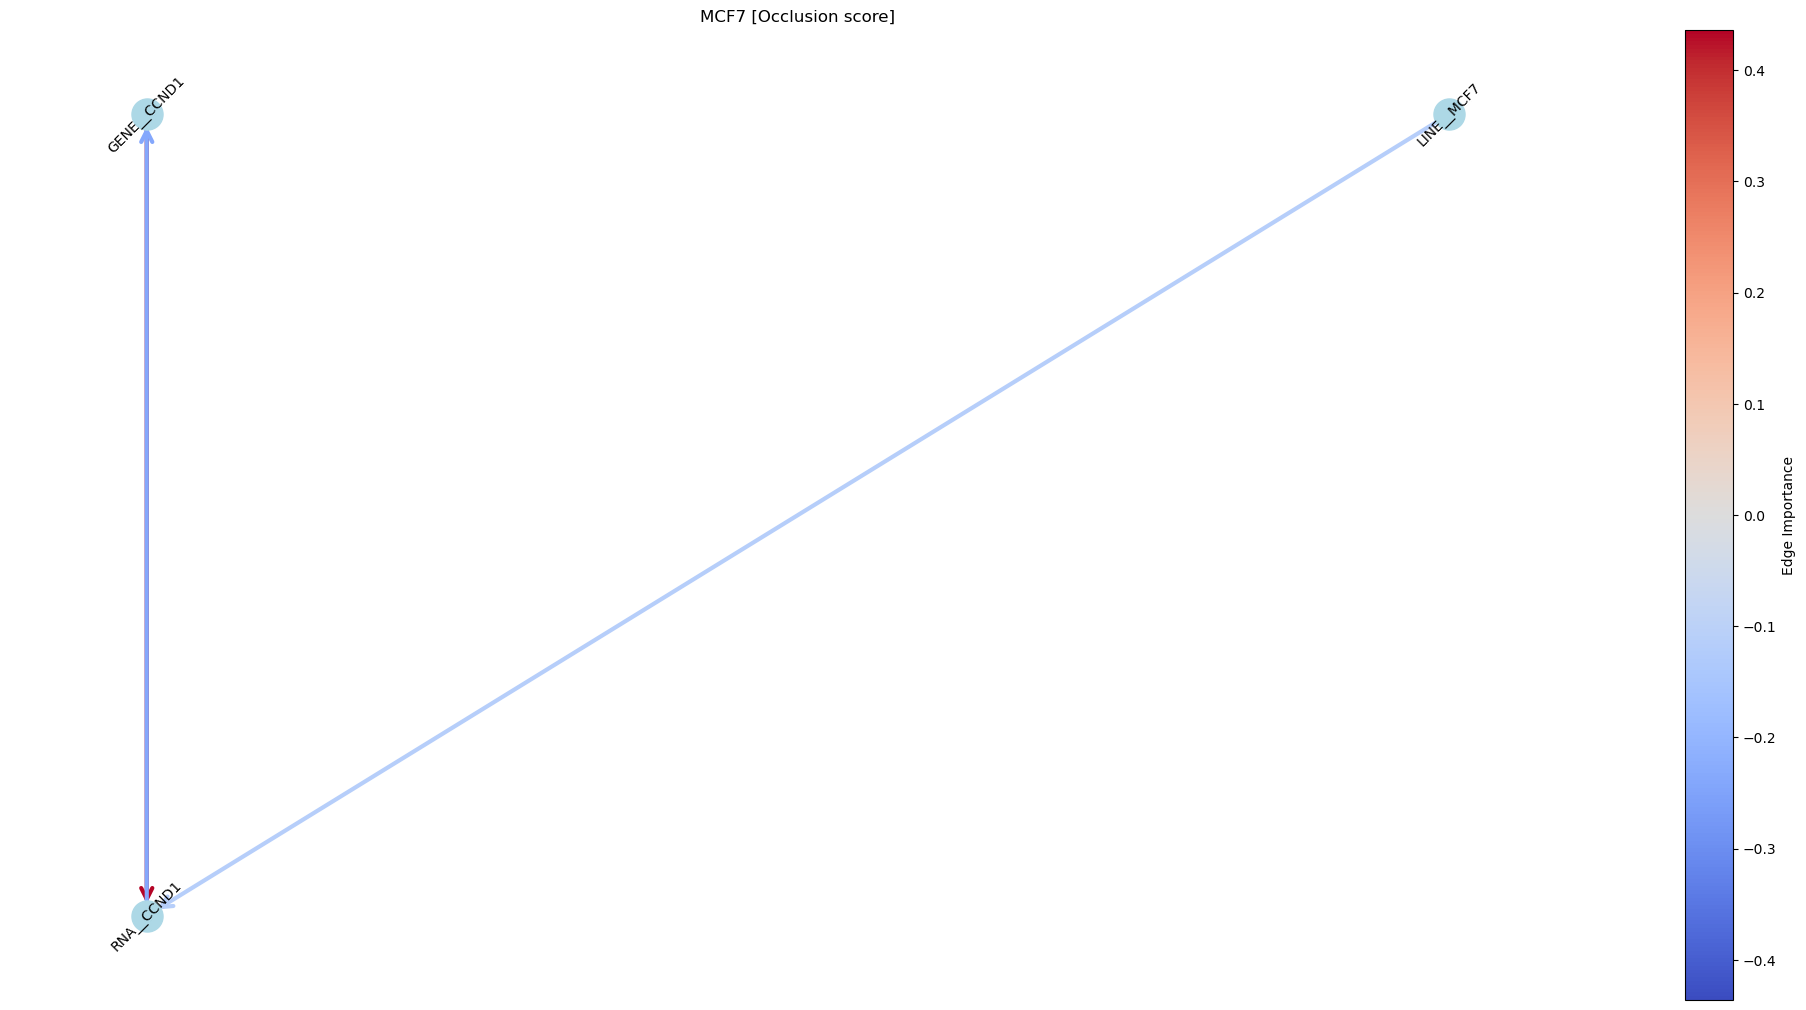

In [ ]:
plot_edge_importance(res2.rename(columns={'occlusion_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [Occlusion score]')

In [ ]:
G = nx.from_pandas_edgelist(res2, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(gsnn_res2, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr2 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr2.res2d.sort_values(by='Adjusted P-value', ascending=True).head(20)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Estrogen-dependent Nuclear Events Downstream O...,0.030848
1,Signaling By Non-Receptor Tyrosine Kinases R-H...,0.041510
2,Extra-nuclear Estrogen Signaling R-HSA-9009391,0.044759
3,EGFR Interacts With Phospholipase C-gamma R-HS...,0.047270
4,Inhibition Of Signaling By Overexpressed EGFR ...,0.047270
5,Signaling By NOTCH R-HSA-157118,0.047270
6,ESR-mediated Signaling R-HSA-8939211,0.047270
7,PTK6 Promotes HIF1A Stabilization R-HSA-8857538,0.047270
8,GRB2 Events In EGFR Signaling R-HSA-179812,0.047270
9,Drug-mediated Inhibition Of CDK4/CDK6 Activity...,0.047270


In [ ]:
# we expect MDAMB231 to have be RB1 deficient and therefore uninvolved, what is the RB1 scores? 

res2_all = gsnn_res2.merge(ig_res2, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res2_all = res2_all.merge(occlusion_res2, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res2_all = res2_all.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs()) 


res2_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5]

,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score


In [ ]:
res2_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].ig_score.sum()

np.float32(0.0)

In [ ]:
res2_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].occlusion_score.sum()

np.float64(0.0)

In [ ]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res2 = explainer.explain(x0_2.to(device), 
                                   target_idx=target_ix, 
                                   target='node')

occlusion_res2.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__RB1')].head().style.hide()

node,score
GENE__RB1,0.000000
GENE__RB1,-0.000000
PROTEIN__RB1CC1,-0.001986
PROTEIN__RB1,-0.017200
RNA__RB1,-0.029708


In [ ]:
explainer = IGExplainer(model.to(device), data)
ig_res2 = explainer.explain(x0_2.to(device), 
                            target_idx=target_ix, 
                            target='node', 
                            reduction='sum')

ig_res2.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__RB1')].head().style.hide()

node,score
GENE__RB1,0.000000
GENE__RB1,0.000000
PROTEIN__RB1CC1,-0.000496
PROTEIN__RB1,-0.000826
RNA__RB1,-0.004641


# comparing GSEA results between CELL 1 and CELL 2 

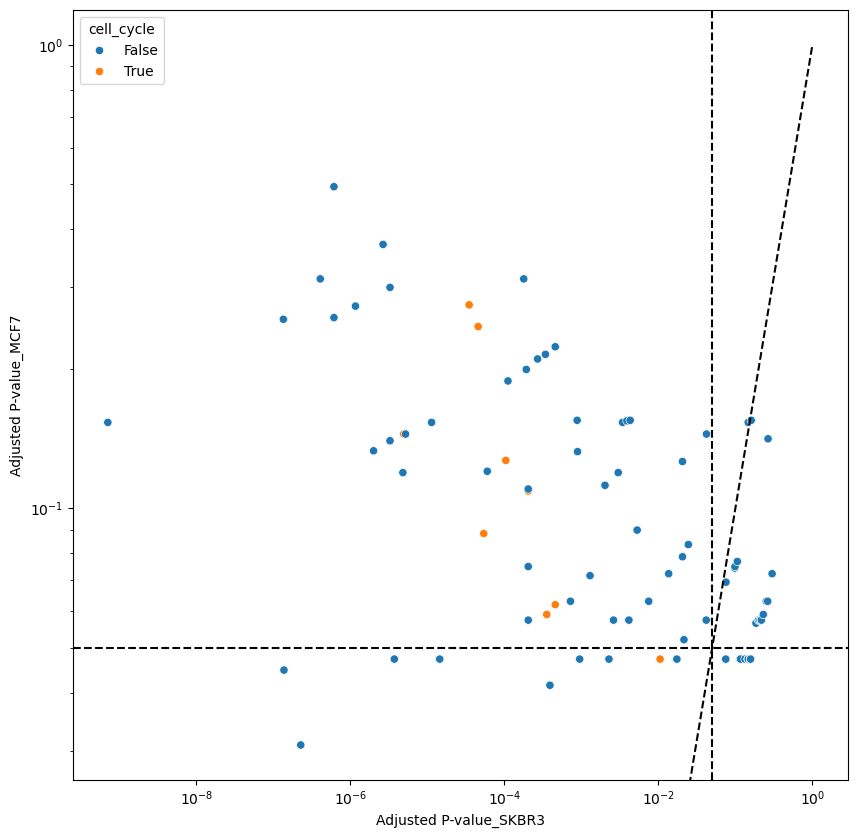

In [ ]:
enr = enr1.res2d.merge(enr2.res2d, on='Term', how='inner')
enr = enr.rename(columns={'Adjusted P-value_x': f'Adjusted P-value_{cell1}', 'Adjusted P-value_y': f'Adjusted P-value_{cell2}'})
enr = enr.assign(cell_cycle = lambda x: x.Term.str.lower().str.contains('cell cycle') | x.Term.str.contains('G1'))

plt.figure(figsize=(10, 10))
sbn.scatterplot(data=enr, x=f'Adjusted P-value_{cell1}', y=f'Adjusted P-value_{cell2}', hue='cell_cycle')
plt.plot([0, 1], [0, 1], 'k--')
plt.xscale('log')
plt.yscale('log')

plt.axvline(0.05, color='k', linestyle='--')
plt.axhline(0.05, color='k', linestyle='--')


# add text labels to outliers (those that are not similar between the two cells)
'''for i, row in enr.iterrows():
    cell1_log_pval = np.log10(row[f'Adjusted P-value_{cell1}'])
    cell2_log_pval = np.log10(row[f'Adjusted P-value_{cell2}'])
    diff = np.abs(cell1_log_pval - cell2_log_pval)
    if diff > 2.5:
        plt.text(row[f'Adjusted P-value_{cell1}'], row[f'Adjusted P-value_{cell2}'], row['Term'], fontsize=12)'''

plt.show()

# Contrastive Explanation 

In [ ]:
ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)
                      

explainer = ContrastiveGSNNExplainer(ode_gsnn, 
                                     data,
                                     hard=False,
                                     beta=5e-4,
                                     lr=1e-1,
                                     prior=5,
                                     iters=250,
                                     free_edges=100)

                                     
cres_gsnn = explainer.explain(x0_1.to(device), 
                              x0_2.to(device), 
                              target_idx=target_ix, 
                              target='edge')

cres_gsnn.head()

Batch size: 1, Target dims: 1
Target Δf mean: -1.484324, std: 0.105089
iter: 249 | loss: 0.8987 | mse: 0.0076 | r2: 0.273 | active edges: 1364 / 43637 | entropy: 0.125751
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 39 / 43637 (0.1%)
Target Δf mean: -1.484324
Subset Δf mean: -1.451823
MSE: 0.007666
R² (across 1x1 elements): 0.2693


,source,target,score
0,PROTEIN__IL4R,PROTEIN__JAK1,0.026407
1,PROTEIN__IL4R,PROTEIN__JAK3,0.042537
2,PROTEIN__IL4R,PROTEIN__JAK2,0.011887
3,PROTEIN__IL4R,PROTEIN__STAT5A,0.027531
4,RNA__hsa-let-7c-3p,RNA__HMGA2,0.019723


In [ ]:
explainer = NoiseTunnel(ContrastiveIGExplainer(model.to(device), data), n_samples=100, noise_std=0.1)

cres_ig = explainer.explain(x0_1.to(device), 
                            x0_2.to(device), 
                            target_idx=target_ix, 
                            element_mask=cres_gsnn.score.values > 0.5,
                            target='edge')

cres_ig.sort_values(by='score', ascending=False).head()


,source,target,score
17580,GENE__PTK2,RNA__PTK2,0.431428
41204,RNA__CCND1,GENE__CCND1,0.424637
17098,GENE__AKT1,RNA__AKT1,0.364268
16455,GENE__PRKACA,RNA__PRKACA,0.248019
17562,GENE__STAT3,RNA__STAT3,0.212580


In [ ]:

explainer = ContrastiveOcclusionExplainer(model.to(device), data)
cres_occ = explainer.explain(x0_1.to(device), 
                             x0_2.to(device), 
                             target_idx=target_ix, 
                             element_mask=cres_gsnn.score.values > 0.5,
                             target='edge')

cres_occ.head()

,source,target,score
0,PROTEIN__IL4R,PROTEIN__JAK1,NaN
1,PROTEIN__IL4R,PROTEIN__JAK3,NaN
2,PROTEIN__IL4R,PROTEIN__JAK2,NaN
3,PROTEIN__IL4R,PROTEIN__STAT5A,NaN
4,RNA__hsa-let-7c-3p,RNA__HMGA2,NaN


In [ ]:
cres = cres_ig.merge(cres_gsnn, on=['source', 'target'], how='inner').rename(columns={'score_x': 'ig_score', 'score_y': 'gsnn_score'})
cres = cres.merge(cres_occ, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
cres = cres[lambda x: x.gsnn_score > 0.5]
cres.head() 

,source,target,ig_score,gsnn_score,occlusion_score
103,RNA__CREB1,PROTEIN__CREB1,0.000984,0.988107,0.041056
4842,PROTEIN__RELA,RNA__CCND1,0.015118,0.970613,0.293633
5876,RNA__hsa-miR-130b*,RNA__CCND1,0.020143,0.701348,0.180971
7630,PROTEIN__MYC,RNA__CCND1,0.061290,0.994387,0.871347
8334,PROTEIN__PIN1,PROTEIN__MYC,0.001658,0.975898,0.077492


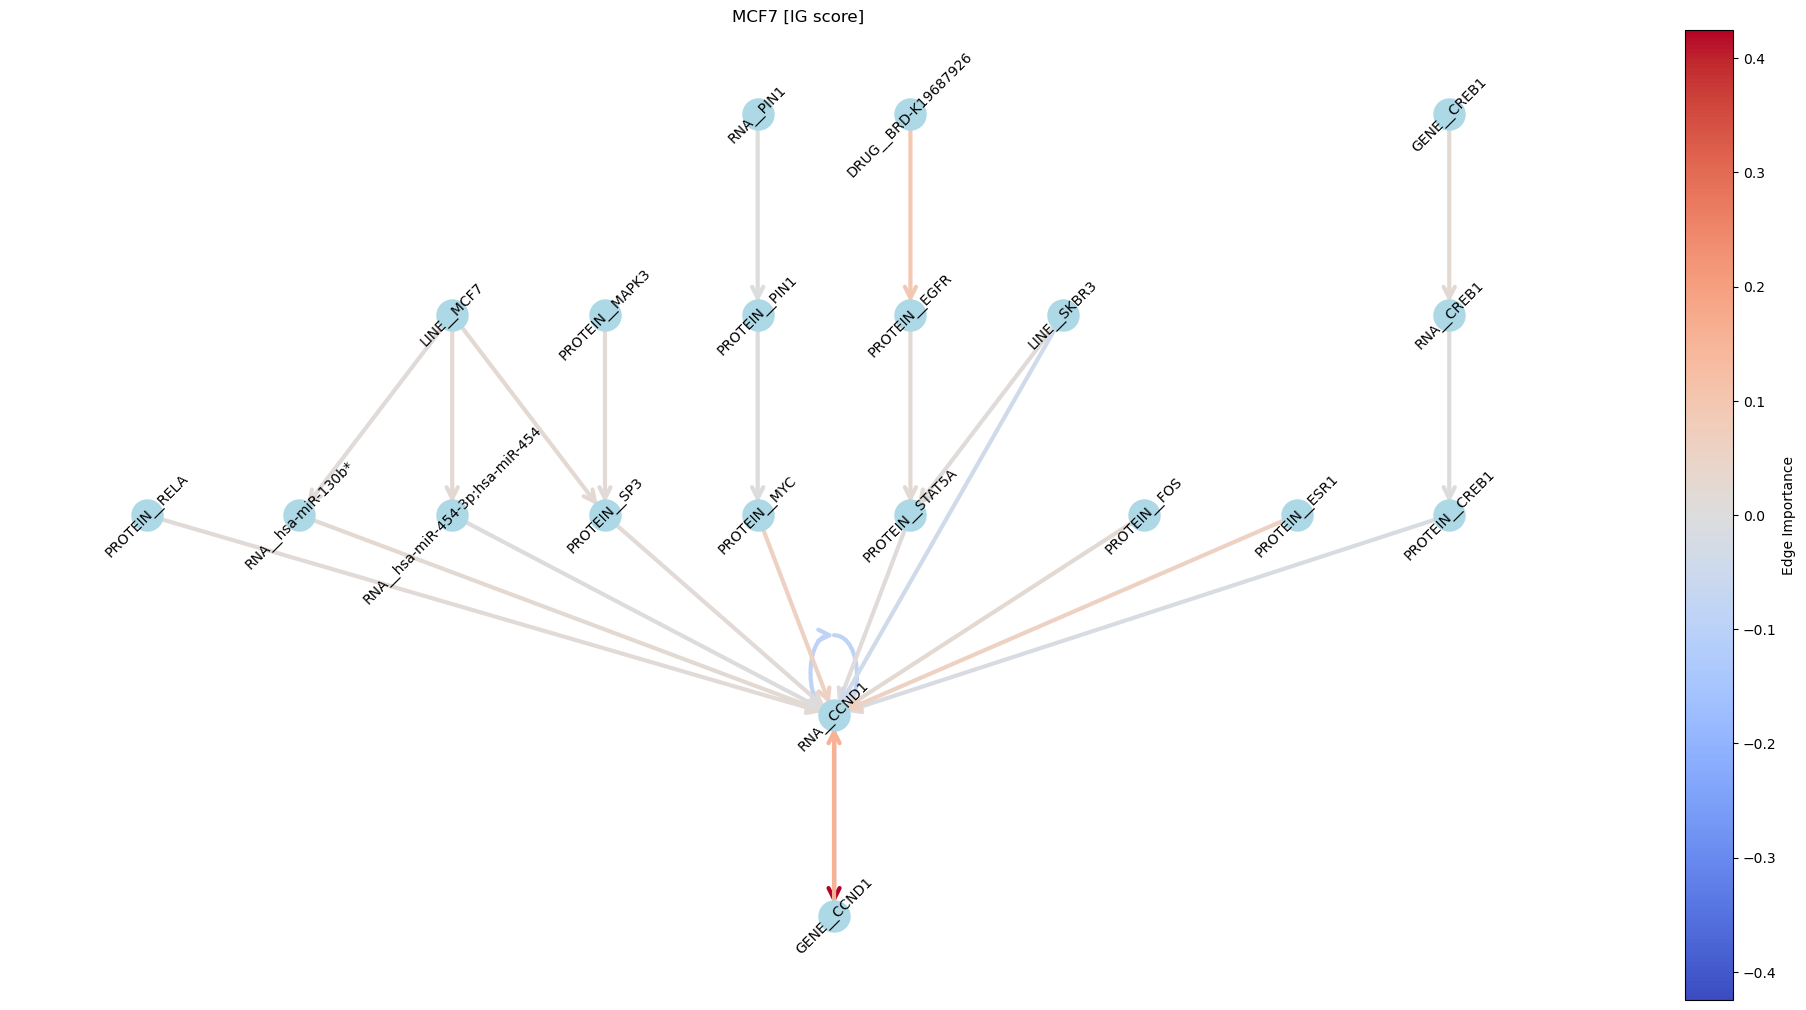

In [ ]:
plot_edge_importance(cres.rename(columns={'ig_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [IG score]')

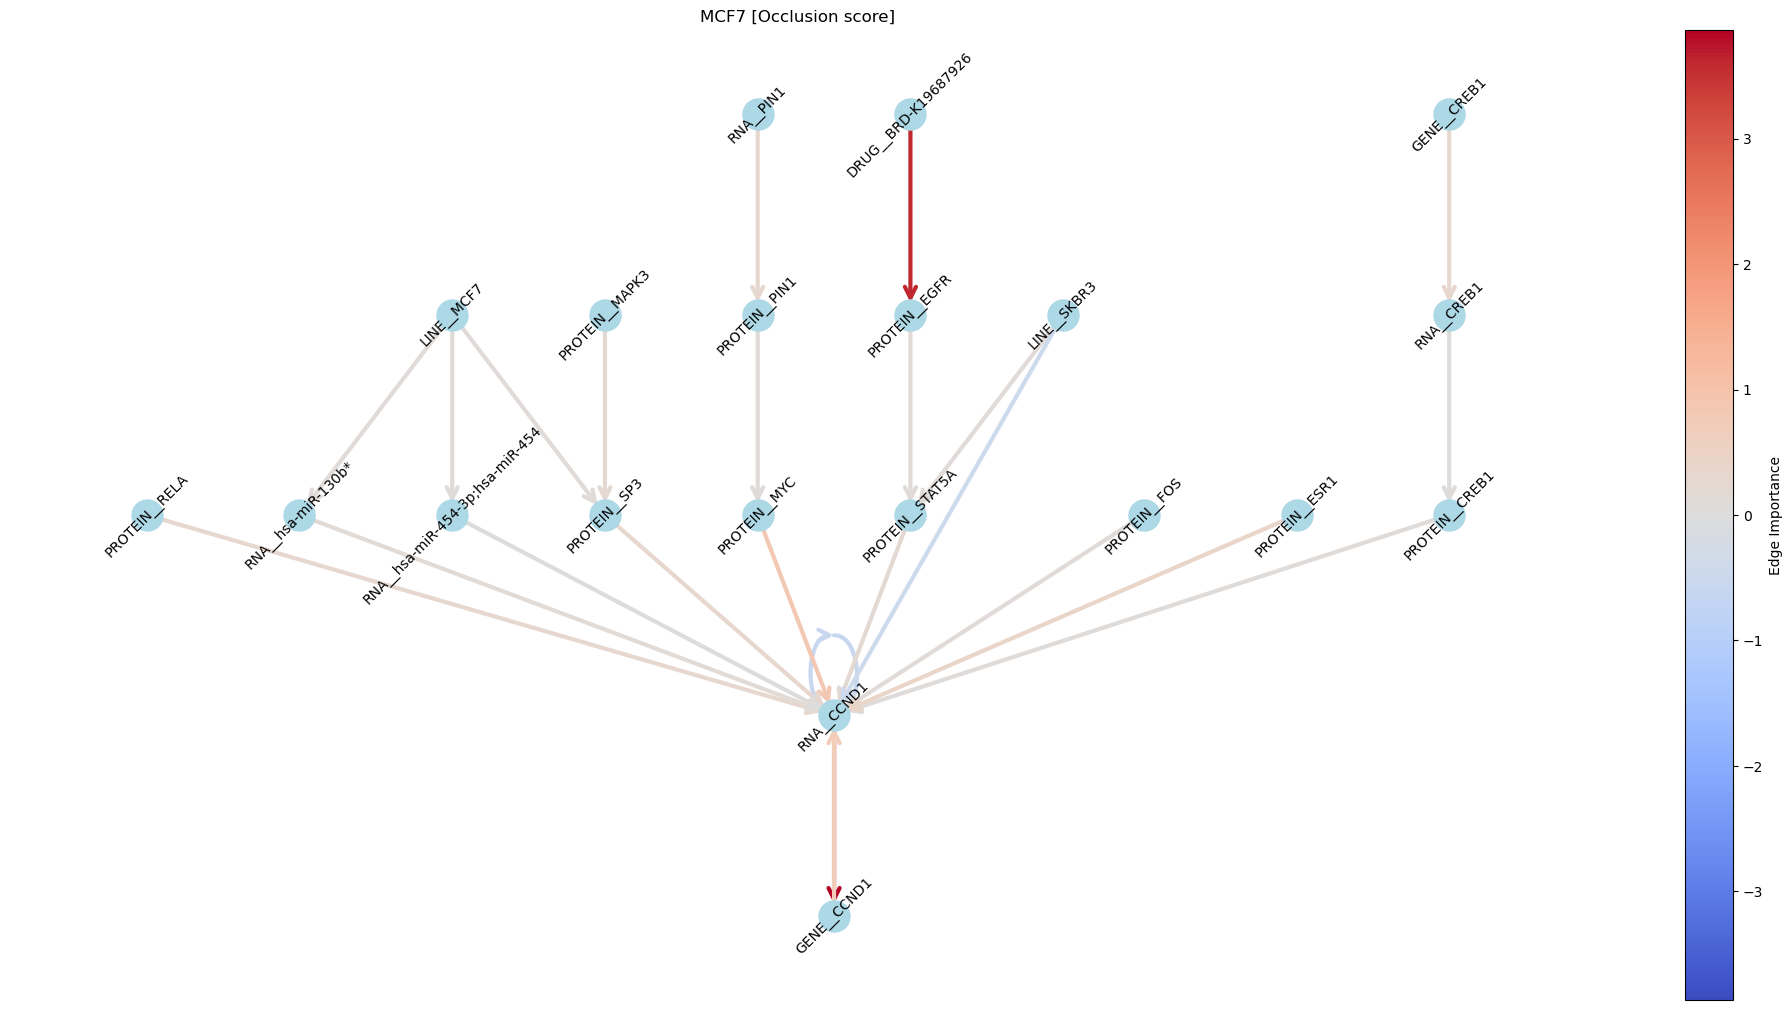

In [ ]:
plot_edge_importance(cres.rename(columns={'occlusion_score': 'score'}), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [Occlusion score]')

In [ ]:
G = nx.from_pandas_edgelist(cres, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(cres_gsnn, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr1 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr1.res2d.sort_values(by='Adjusted P-value', ascending=True).head(20)[['Term', 'Adjusted P-value']].style.hide()

Term,Adjusted P-value
Estrogen-dependent Nuclear Events Downstream Of ESR-membrane Signaling R-HSA-9634638,0.000000
Extra-nuclear Estrogen Signaling R-HSA-9009391,0.000001
Signaling By Interleukins R-HSA-449147,0.000004
Transcriptional Regulation By RUNX2 R-HSA-8878166,0.000016
ESR-mediated Signaling R-HSA-8939211,0.000018
Disease R-HSA-1643685,0.000029
Interleukin-4 And Interleukin-13 Signaling R-HSA-6785807,0.000043
Signaling By Nuclear Receptors R-HSA-9006931,0.000049
Cytokine Signaling In Immune System R-HSA-1280215,0.000049
Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers R-HSA-5663202,0.000174


In [ ]:
explainer = ContrastiveIGExplainer(model.to(device), data)

cres_ig = explainer.explain(x0_1.to(device), 
                            x0_2.to(device), 
                            target_idx=target_ix, 
                            target='node')

#cres_ig[lambda x: x.node.str.contains(f'__RB1')].sort_values(by='score', ascending=False).head()
cres_ig.sort_values(by='score', ascending=False).head().style.hide()


node,score
RNA__CCND1,1.076921
PROTEIN__TP53,0.251567
PROTEIN__MYC,0.198514
PROTEIN__MAPK3,0.157843
PROTEIN__EGFR,0.148900


In [ ]:
cres_ig.sort_values(by='score', ascending=False).tail()

,node,score
2027,RNA__hsa-miR-17-5p,-0.037335
221,RNA__hsa-miR-302a-3p,-0.038221
859,PROTEIN__FOXM1,-0.039141
2054,PROTEIN__RET,-0.045106
1286,RNA__hsa-miR-502-5p,-0.066556


In [ ]:
explainer = ContrastiveOcclusionExplainer(model.to(device), data)
cres_occ = explainer.explain(x0_1.to(device), 
                             x0_2.to(device), 
                             target_idx=target_ix, 
                             target='node')

cres_occ.sort_values(by='score', ascending=False).head().style.hide()

node,score
RNA__CCND1,3.865070
PROTEIN__EGFR,2.514402
PROTEIN__MAP2K1,0.832253
PROTEIN__TP53,0.749340
PROTEIN__MYC,0.721998


In [ ]:
cres_occ.sort_values(by='score', ascending=False).tail()

,node,score
1105,RNA__hsa-miR-106b-3p,-0.131404
315,RNA__hsa-miR-122*,-0.161488
1144,RNA__hsa-miR-27a,-0.168967
1260,PROTEIN__GLI2,-0.169518
1286,RNA__hsa-miR-502-5p,-0.172163


In [ ]:
G = nx.from_pandas_edgelist(cres[lambda x: x.gsnn_score > 0.5],
                            source='source', 
                            target='target', 
                            create_using=nx.DiGraph, 
                            edge_attr='ig_score')

centrality = nx.betweenness_centrality(G)
centrality = pd.Series(centrality, index=G.nodes())

centrality.sort_values(ascending=False).head(25)

RNA__CCND1                         0.012146
PROTEIN__CREB1                     0.002699
PROTEIN__MYC                       0.002699
PROTEIN__STAT5A                    0.002699
PROTEIN__PIN1                      0.002024
RNA__CREB1                         0.002024
PROTEIN__EGFR                      0.002024
PROTEIN__SP3                       0.001799
RNA__hsa-miR-454-3p;hsa-miR-454    0.000450
RNA__hsa-miR-130b*                 0.000450
PROTEIN__RELA                      0.000000
PROTEIN__FOS                       0.000000
PROTEIN__ESR1                      0.000000
PROTEIN__MAPK3                     0.000000
RNA__PIN1                          0.000000
GENE__CCND1                        0.000000
GENE__PRKACA                       0.000000
RNA__PRKACA                        0.000000
GENE__CREB1                        0.000000
GENE__TP53                         0.000000
RNA__TP53                          0.000000
GENE__CDK1                         0.000000
RNA__CDK1                       